
# Exploring Convolutional Layers Through Data and Experiments -- Tomas Espitia

In [68]:
%pip install torch torchvision pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\tomas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [69]:
from __future__ import annotations

from typing import Tuple, Dict
import os
import json
import tarfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


Dataset
Para el desarrollo de este trabajo se utiliza el dataset Fashion-MNIST, un conjunto de datos público ampliamente usado en tareas de clasificación de imágenes. Este dataset está compuesto por imágenes en escala de grises de 28 × 28 píxeles, distribuidas en 10 clases que representan diferentes tipos de prendas de vestir, como camisetas, pantalones, abrigos, sandalias, zapatillas y bolsos.

Fashion-MNIST es adecuado para el estudio de redes neuronales convolucionales debido a que las clases se diferencian principalmente por patrones espaciales locales, tales como bordes, contornos y texturas, los cuales pueden aparecer en distintas posiciones dentro de la imagen. Esto permite analizar el inductive bias introducido por las capas convolucionales, específicamente la conectividad local y la compartición de pesos, y comparar su desempeño frente a modelos totalmente conectados.

Los datos se cargan utilizando la librería torchvision.datasets.FashionMNIST, lo que garantiza la reproducibilidad del experimento y evita procesos manuales de descarga y preparación del conjunto de datos. Como etapa de preprocesamiento, se realiza la conversión de las imágenes a tensores y se aplica normalización, con el fin de estabilizar y mejorar el proceso de entrenamiento del modelo.

# 1. Dataset Exploration (EDA)

En esta sección se analiza la estructura del dataset Fashion-MNIST con el objetivo de comprender sus principales características antes de definir y diseñar las arquitecturas de la red neuronal. Para ello, se revisan aspectos como el tamaño del conjunto de datos, la distribución de las clases, la forma de las imágenes (dimensiones y número de canales), ejemplos representativos por clase y el preprocesamiento aplicado, específicamente la normalización.

Este análisis busca proporcionar una comprensión general de la naturaleza del problema de clasificación, sin entrar en un estudio estadístico exhaustivo, permitiendo así tomar decisiones informadas sobre el diseño y entrenamiento de los modelos de red neuronal.

In [70]:
class_names = [
    "T-shirt/top","Trouser","Pullover","Dress","Coat",
    "Sandal","Shirt","Sneaker","Bag","Ankle boot"
]


In [71]:
#Nombre de las clase
#Vamos a explorar el Dataset
transform = transforms.Compose([
    transforms.ToTensor(),     
    transforms.Normalize((0.2860,), (0.3530,)) 
])


In [72]:
# Cargamos el dataset
train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)


In [73]:
# Miramos el tamañi que tiene nuestro dataset
print("Tamaño conjunto de entrenamiento:", len(train_dataset))
print("Tamaño conjunto de prueba:", len(test_dataset))


Tamaño conjunto de entrenamiento: 60000
Tamaño conjunto de prueba: 10000


In [74]:
#Aca vemos las dimensiones de las imagenes
image, label = train_dataset[0]
print("Dimensión de la imagen:", image.shape)
print("Etiqueta:", label, "-", class_names[label])


Dimensión de la imagen: torch.Size([1, 28, 28])
Etiqueta: 9 - Ankle boot


In [75]:
train_labels = pd.Series([y for _, y in train_dataset])
test_labels = pd.Series([y for _, y in test_dataset])

print("Distribución de clases (train):")
print(train_labels.value_counts().sort_index())

print("\nDistribución de clases (test):")
print(test_labels.value_counts().sort_index())


Distribución de clases (train):
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

Distribución de clases (test):
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


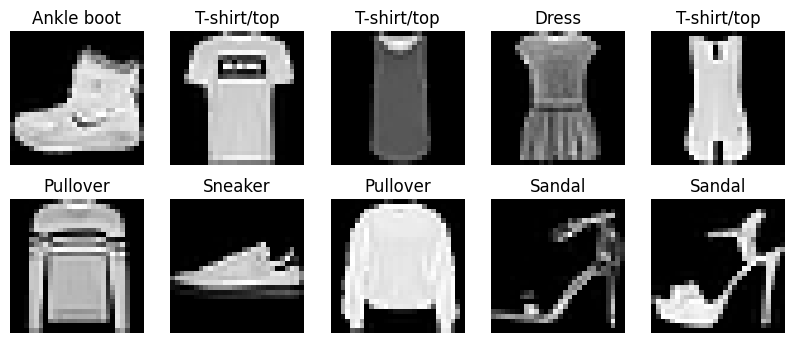

In [76]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    img, lbl = train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[lbl])
    ax.axis("off")

plt.show()


Para este trabajo se utiliza el dataset Fashion-MNIST, un conjunto de datos público compuesto por imágenes de prendas de vestir en escala de grises. El dataset está conformado por 60.000 imágenes de entrenamiento y 10.000 imágenes de prueba, distribuidas en 10 clases que representan distintos tipos de ropa y calzado.

Cada imagen tiene una resolución de 28 × 28 píxeles y cuenta con un único canal, por lo que los datos pueden representarse como tensores de dimensión (28, 28, 1). Esta estructura resulta adecuada para el uso de redes neuronales convolucionales, ya que permite conservar la información espacial presente en las imágenes.

La distribución de las clases es aproximadamente balanceada tanto en el conjunto de entrenamiento como en el conjunto de prueba, lo cual ayuda a reducir posibles sesgos durante el proceso de aprendizaje del modelo.

# Baseline Model (Non-Convolutional)

In [77]:
# Definicion del modelo MLP

import torch
import torch.nn as nn

class MLPBaseline(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),            
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [78]:
# Función para contar parámetros entrenables

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [79]:
# Definición de la clase Trainer

import torch.optim as optim
from torch.utils.data import DataLoader

class Trainer:
    def __init__(self, model: nn.Module, device: torch.device, lr: float = 1e-3):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

    def train_epoch(self, loader: DataLoader) -> float:
        self.model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in loader:
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_loss = running_loss / len(loader)
        acc = correct / total
        return avg_loss, acc

    def evaluate(self, loader: DataLoader) -> float:
        self.model.eval()
        running_loss = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                running_loss += loss.item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_loss = running_loss / len(loader)
        acc = correct / total
        return avg_loss, acc


In [80]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [ ]:
# Entrenamiento del modelo baseline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

baseline_model = MLPBaseline(num_classes=10)
baseline_trainer = Trainer(baseline_model, device, lr=1e-3)

print("Baseline parameters:", count_parameters(baseline_model))
print(baseline_model)

EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = baseline_trainer.train_epoch(train_loader)
    val_loss, val_acc = baseline_trainer.evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")


Baseline parameters: 203530
MLPBaseline(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Epoch 1/5 | train_loss=0.4534, train_acc=0.8349 | val_loss=0.4099, val_acc=0.8488
Epoch 2/5 | train_loss=0.3469, train_acc=0.8717 | val_loss=0.3675, val_acc=0.8671
Epoch 3/5 | train_loss=0.3097, train_acc=0.8842 | val_loss=0.3617, val_acc=0.8677
Epoch 4/5 | train_loss=0.2866, train_acc=0.8949 | val_loss=0.3454, val_acc=0.8745


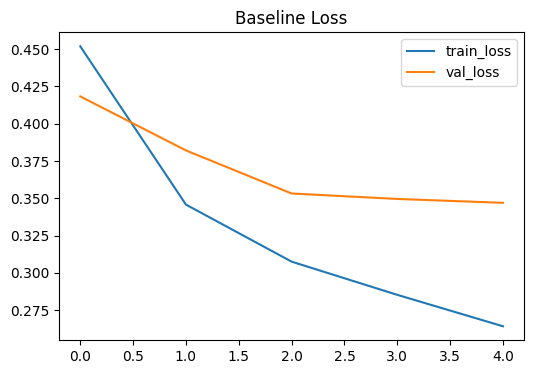

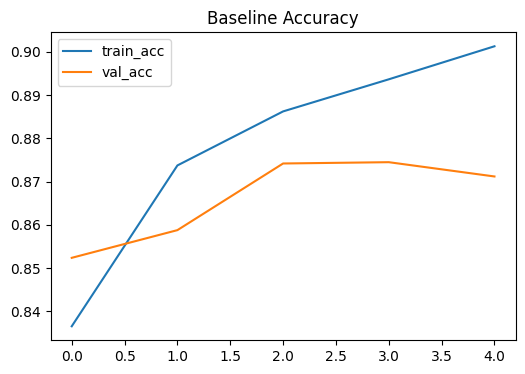

In [ ]:
# grafica de Curvas de entrenamiento
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Baseline Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Baseline Accuracy")
plt.legend()
plt.show()


Como modelo base se implementó una red neuronal totalmente conectada (MLP), sin el uso de capas convolucionales. Este modelo se utiliza como línea de referencia para evaluar el impacto que tiene la incorporación de convoluciones en tareas de clasificación de imágenes.

- La arquitectura del modelo es la siguiente:

Entrada: imagen de 28 × 28 píxeles con un canal

Flatten: transforma la imagen en un vector de 784 características

Capa densa oculta: 256 neuronas con función de activación ReLU

Capa de salida: 10 neuronas (logits) correspondientes a las clases del problema

- De forma funcional, el modelo puede representarse como:

Flatten → Dense(256) + ReLU → Dense(10)

Número de parámetros

El número de parámetros entrenables se obtiene a partir del conteo directo del modelo, considerando la suma de los pesos y sesgos de cada capa. Este valor permite dimensionar la complejidad del modelo y compararla posteriormente con arquitecturas convolucionales.

- El modelo se entrena durante varios epochs y se reportan las siguientes métricas:

Pérdida y accuracy en el conjunto de entrenamiento

Pérdida y accuracy en el conjunto de validación o prueba

Estos resultados establecen un punto de referencia cuantitativo previo a la introducción de capas convolucionales.

- Este modelo presenta varias limitaciones al trabajar con datos de tipo imagen:

El uso de la operación Flatten elimina explícitamente la estructura espacial de la imagen, perdiendo la relación de vecindad entre píxeles.

Los patrones locales, como bordes y contornos, no se modelan de manera eficiente.

El modelo es sensible a pequeñas traslaciones o cambios en la posición de la prenda dentro de la imagen.

Para aproximar relaciones espaciales complejas, se requieren capas densas con un alto número de parámetros, lo que suele afectar negativamente la capacidad de generalización en comparación con una CNN.